# Etap II — Bootstrap krzywej przeżycia z notowań CDS

**Projekt CVA UEP — Spring 2026, data obliczeniowa: 31.12.2025**

Z rynkowych spreadów CDS kontrahenta wyznaczamy krzywą prawdopodobieństw przeżycia $PS(t)$ oraz defaultu $PD(t)$ — bezpośrednie wejście do wyceny CVA w punkcie V.

**Założenia:** recovery $R = 40\%$ (LGD $= 60\%$), krok miesięczny $\Delta t = 1/12$, liniowa interpolacja spreadów między tenorami, dyskonto EUR z arkusza wejściowego.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import PercentFormatter

## 1. Dane wejściowe i interpolacja spreadów CDS

Wczytujemy czynniki dyskontowe EUR (`EUR_DF`) oraz spready CDS dla tenorów 6M / 1Y / 2Y / 3Y (30.5 / 39.4 / 69.35 / 96.7 bps) i interpolujemy je liniowo na siatkę miesięczną (0–36 m).

In [ ]:
time_data = pd.read_excel("data/data_part_II.xlsx", sheet_name='timeData')


## 2. Bootstrap krzywej przeżycia (PS → PD)

Iteracyjnie wyznaczamy $PS_n$ z warunku równowagi nogi protection i nogi premium kontraktu CDS:

$$LGD \sum_i (PS_{i-1}-PS_i)\,DF_i \;=\; S_n\,\Delta t \sum_i PS_i\,DF_i$$

Stąd PD skumulowane $= 1 - PS$, a PD krańcowe w okresie $i$ to $PS_{i-1} - PS_i$.

In [38]:
df_time = pd.read_excel('data/data_part_II.xlsx')
max_month = min(36, df_time['Month'].max())
df_time = df_time[df_time['Month'] <= max_month]

months = df_time['Month'].values
DF_EUR = df_time['EUR_DF'].values

months_cds = np.array([
    0, 
    6, 
    12, 
    24, 
    36
    ])
spreads_cds = np.array([
    0.0, 
    30.5, 
    39.4, 
    69.35, 
    96.7
    ]) / 10000

interp_func = interp1d(months_cds, spreads_cds, kind='linear')
spreads_monthly = interp_func(months)

R = 0.4
LGD = 1 - R
dt = 1 / 12
PS = np.ones(len(months))

for n in range(1, len(months)):
    S_n = spreads_monthly[n]
    DF_n = DF_EUR[n]
    sum_terms = 0
    for i in range(1, n):
        term_LGD = LGD * (PS[i-1] - PS[i])
        term_Prem = S_n * dt * PS[i]
        sum_terms += DF_EUR[i] * (term_LGD - term_Prem)
    numerator = LGD * DF_n * PS[n-1] + sum_terms
    denominator = DF_n * (LGD + S_n * dt)
    PS[n] = numerator / denominator
PD_cumulative = 1 - PS
PD_marginal = np.zeros(len(months))
for i in range(1, len(months)):
    PD_marginal[i] = PS[i-1] - PS[i]

## 3. Wyniki tabelaryczne

Podgląd krzywej: spread, prawdopodobieństwo przeżycia i skumulowane PD w kolejnych miesiącach.

In [39]:
pd.DataFrame({
    'Miesiąc': months,
    'Spread CDS': spreads_monthly,
    'Survival Prob (PS)': PS,
    'Cumulative PD': PD_cumulative
}).head()

,Miesiąc,Spread CDS,Survival Prob (PS),Cumulative PD
0,0,0.000000,1.000000,0.000000
1,1,0.000508,0.999929,0.000071
2,2,0.001017,0.999718,0.000282
3,3,0.001525,0.999364,0.000636
4,4,0.002033,0.998870,0.001130


## 4. Krzywa spreadów CDS

Punkty rynkowe (czerwone) vs. interpolacja liniowa (zielona) — kontrola poprawności kalibracji.

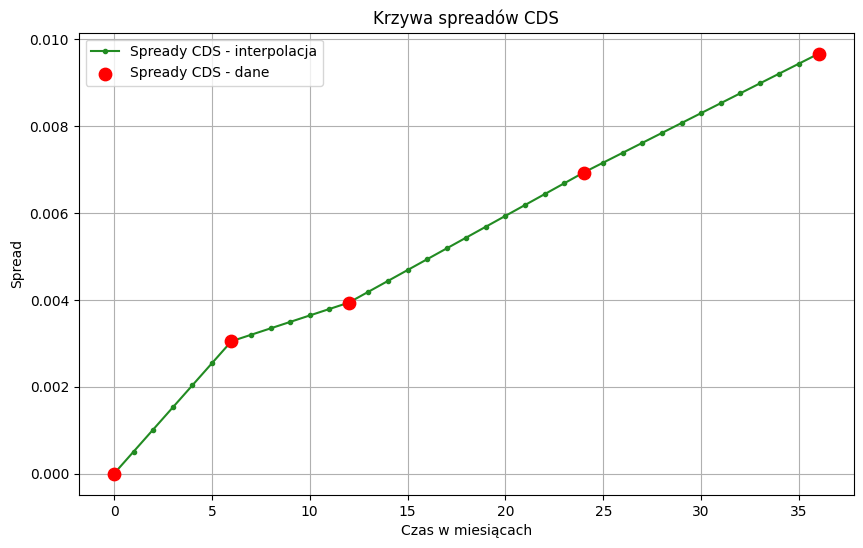

In [41]:
spreads_cds = np.array([
    0.0, 
    30.5, 
    39.4, 
    69.35, 
    96.7
]) / 10000


months = np.arange(len(spreads_monthly))
cds_months = np.array([0, 6, 12, 24, 36])

plt.figure(figsize=(10,6))
plt.plot(
    months, 
    spreads_monthly, 
    marker='o',
    markersize=3,
    linestyle='-',
    color='forestgreen',
    label='Spready CDS - interpolacja',
    zorder=2
)
plt.scatter(
    cds_months, 
    spreads_cds, 
    label='Spready CDS - dane',
    marker='o',
    color='red',
    s=80,
    zorder=3
)
plt.xlabel('Czas w miesiącach')
plt.ylabel('Spread')
plt.title('Krzywa spreadów CDS')
plt.legend()
plt.grid()
plt.show()

## 5. Krzywa prawdopodobieństwa przeżycia (PS)

Monotonicznie malejąca — $PS$ spada wraz z horyzontem, zgodnie z rosnącym ryzykiem defaultu.

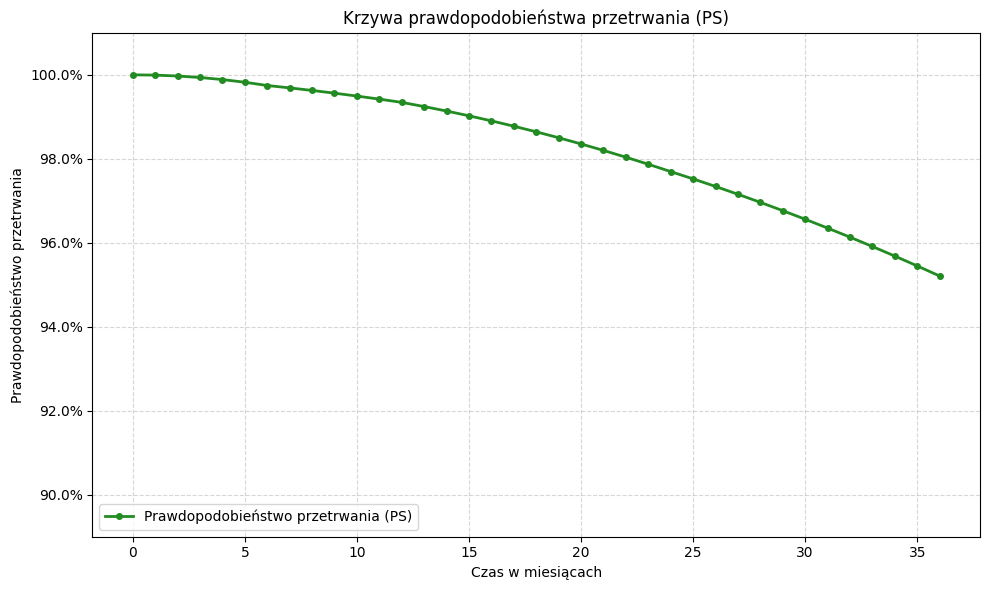

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(months, PS, 
         marker='o',
         markersize=4,
         linestyle='-',
         color='forestgreen',
         linewidth=2,
         label='Prawdopodobieństwo przetrwania (PS)'
         )
plt.xlabel('Czas w miesiącach')
plt.ylabel('Prawdopodobieństwo przetrwania')
plt.title('Krzywa prawdopodobieństwa przetrwania (PS)')
ymin, ymax = 0.9, 1.0
margin = 0.01
plt.ylim(ymin - margin, ymax + margin)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Wektor PS

Wynikowy wektor $PS$ — gotowe wejście do punktu V (CVA).

In [43]:
PS

array([1.        , 0.9999294 , 0.99971752, 0.99936432, 0.99886979,
       0.99823397, 0.99745693, 0.9968899 , 0.99628183, 0.99563275,
       0.99494268, 0.99421166, 0.99343972, 0.99244294, 0.99137726,
       0.99024277, 0.98903958, 0.98776781, 0.98642757, 0.98501901,
       0.98354227, 0.9819975 , 0.98038487, 0.97870454, 0.9769567 ,
       0.9752175 , 0.97341708, 0.97155561, 0.96963328, 0.96765029,
       0.96560685, 0.96350317, 0.96133946, 0.95911596, 0.95683289,
       0.95449051, 0.95208904])